# ZeroTA Session Monitoring Model
## Continuous Session Risk Detection using Isolation Forest

### Objective
This notebook builds the real-time session monitoring engine for the ZeroTA project.

It detects suspicious user behavior during active sessions using:
- file access patterns
- removable media usage
- after-hours activity
- email volume
- device behavior
- trust score logic

### Model
Isolation Forest

### Output Files
- session_model.pkl
- session_scaler.pkl
- session_feature_cols.json

In [9]:
# ==========================================
# Imports
# ==========================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [10]:
# ==========================================
# Mount Drive & Locate Dataset
# ==========================================

from google.colab import drive
drive.mount("/content/drive")

CERT_DIR = "/content/drive/MyDrive/session dataset"

if os.path.exists(CERT_DIR):
    print("Dataset folder found.")

    for file in sorted(os.listdir(CERT_DIR)):
        path = os.path.join(CERT_DIR, file)
        if os.path.isfile(path):
            size_mb = os.path.getsize(path) / 1e6
            print(f"{file:15s} {size_mb:.2f} MB")
else:
    print("Dataset folder not found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset folder found.
device.csv      139.54 MB
email.csv       1362.10 MB
file.csv        1331.30 MB
logon.csv       241.64 MB


In [11]:
# ==========================================
# Preview Dataset Files
# ==========================================

def preview_csv(filename, rows=5):
    path = os.path.join(CERT_DIR, filename)

    try:
        df = pd.read_csv(path, nrows=rows)
        print(f"\nLoaded: {filename}")
        print("Columns:", df.columns.tolist())
        display(df)
    except Exception as e:
        print(f"Error loading {filename}: {e}")

preview_csv("logon.csv")
preview_csv("file.csv")
preview_csv("device.csv")
preview_csv("email.csv")


Loaded: logon.csv
Columns: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{F3X8-Y2GT43DR-4906OHBL},01/02/2010 02:19:18,DNS1758,PC-0414,Logon
1,{B4Q0-D0GM24KN-3704MAII},01/02/2010 02:31:12,DNS1758,PC-0414,Logoff
2,{T7J1-D4HK34KV-5476TCIJ},01/02/2010 02:34:02,DNS1758,PC-5313,Logon
3,{S4Y6-D8MQ05SA-0759HLIS},01/02/2010 02:53:30,DNS1758,PC-5313,Logoff
4,{F3P0-E7FH78CV-4874FRGZ},01/02/2010 04:07:31,DNS1758,PC-0012,Logon



Loaded: file.csv
Columns: ['id', 'date', 'user', 'pc', 'filename', 'activity', 'to_removable_media', 'from_removable_media', 'content']


,id,date,user,pc,filename,activity,to_removable_media,from_removable_media,content
0,{F3E2-X3MV05YQ-3516SZDT},01/02/2010 07:19:41,SDH2394,PC-5849,R:\60WBQE7S.doc,File Open,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
1,{I6N1-Z7VL92UY-8715ESKQ},01/02/2010 07:21:30,SDH2394,PC-5849,R:\0VGILDW8.pdf,File Write,True,False,25-50-44-46-2D ---- Bengali As do many other T...
2,{G4X5-J7MH70FV-8936QVSB},01/02/2010 07:22:11,SDH2394,PC-5849,R:\60WBQE7S.doc,File Copy,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
3,{M2M7-Z5ST21EU-6704NSKO},01/02/2010 07:24:06,SDH2394,PC-5849,R:\22B5gX4\H8Y96RRE.doc,File Write,True,False,D0-CF-11-E0-A1-B1-1A-E1 After the death of his...
4,{R0A9-O9XB25PE-9236MALV},01/02/2010 07:24:45,SDH2394,PC-5849,R:\SDH2394\7XRCV2N5.pdf,File Copy,True,False,25-50-44-46-2D Although he restored some of th...



Loaded: device.csv
Columns: ['id', 'date', 'user', 'pc', 'file_tree', 'activity']


,id,date,user,pc,file_tree,activity
0,{Z2Q8-K3AV28BE-9353JIRT},01/02/2010 07:17:18,SDH2394,PC-5849,R:\;R:\22B5gX4;R:\SDH2394,Connect
1,{C7F1-G7LE60RU-2483DAXS},01/02/2010 07:22:42,JKS2444,PC-6961,R:\;R:\JKS2444,Connect
2,{T9A4-D4RV69OF-1704NINW},01/02/2010 07:31:42,CBA1023,PC-1570,R:\;R:\42gY283;R:\48rr4y2;R:\59ntt61;R:\76xCQG...,Connect
3,{S8L0-O6QQ15NL-0636OYNV},01/02/2010 07:33:28,GNT0221,PC-6427,R:\;R:\GNT0221,Connect
4,{U0F1-R1FX27FM-6954TTVU},01/02/2010 07:33:55,JKS2444,PC-6961,NaN,Disconnect



Loaded: email.csv
Columns: ['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...


In [12]:
# ==========================================
# Load Full CERT Dataset Files
# ==========================================

print("Loading full files...\n")

logon = pd.read_csv(
    os.path.join(CERT_DIR, "logon.csv"),
    usecols=["date", "user", "pc", "activity"]
)

file_df = pd.read_csv(
    os.path.join(CERT_DIR, "file.csv"),
    usecols=[
        "date", "user", "pc", "filename", "activity",
        "to_removable_media", "from_removable_media"
    ]
)

device_df = pd.read_csv(
    os.path.join(CERT_DIR, "device.csv"),
    usecols=["date", "user", "pc", "activity"]
)

email_df = pd.read_csv(
    os.path.join(CERT_DIR, "email.csv"),
    usecols=["date", "user", "pc", "to", "from", "size", "attachments"]
)

print("logon :", logon.shape)
print("file  :", file_df.shape)
print("device:", device_df.shape)
print("email :", email_df.shape)

Loading full files...

logon : (3530285, 4)
file  : (2014883, 7)
device: (1551828, 4)
email : (2629979, 7)


In [13]:
# ==========================================
# Date Feature Engineering
# ==========================================

for df in [logon, file_df, device_df, email_df]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["day"] = df["date"].dt.date
    df["hour"] = df["date"].dt.hour
    df["is_afterhours"] = (
        (df["hour"] < 8) | (df["hour"] > 18)
    ).astype(int)

print("Date features created successfully.")

Date features created successfully.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

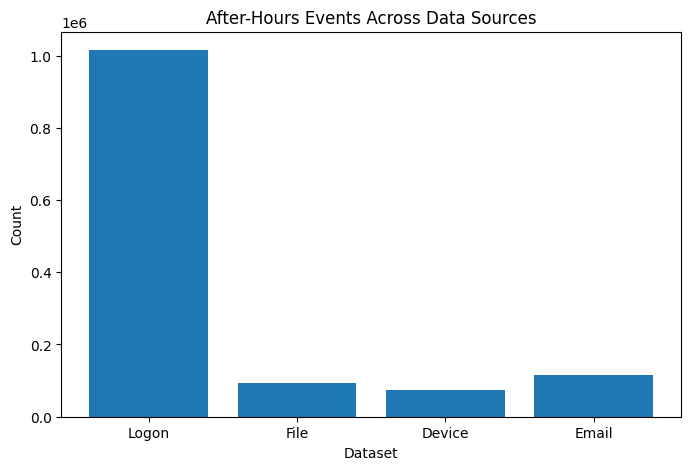

In [15]:
# ==========================================
# Visualization: After-Hours Activity Overview
# ==========================================

afterhours_summary = {
    "Logon": logon["is_afterhours"].sum(),
    "File": file_df["is_afterhours"].sum(),
    "Device": device_df["is_afterhours"].sum(),
    "Email": email_df["is_afterhours"].sum()
}

plt.figure(figsize=(8,5))
plt.bar(afterhours_summary.keys(), afterhours_summary.values())
plt.title("After-Hours Events Across Data Sources")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.show()

In [8]:
# ==========================================
# Build Session-Level Features
# ==========================================

# Logon features
logon_features = logon.groupby(["user", "day"]).agg(
    logon_count=("activity", lambda x: (x == "Logon").sum()),
    logoff_count=("activity", lambda x: (x == "Logoff").sum()),
    afterhours_logon=("is_afterhours", "sum")
).reset_index()

# File features
file_features = file_df.groupby(["user", "day"]).agg(
    file_access_count=("filename", "count"),
    usb_write_count=("to_removable_media", "sum"),
    usb_read_count=("from_removable_media", "sum"),
    afterhours_file_access=("is_afterhours", "sum")
).reset_index()

# Device features
device_features = device_df.groupby(["user", "day"]).agg(
    usb_connect_count=("activity", lambda x: (x == "Connect").sum()),
    usb_disconnect_count=("activity", lambda x: (x == "Disconnect").sum()),
    afterhours_device=("is_afterhours", "sum")
).reset_index()

# Email features
email_features = email_df.groupby(["user", "day"]).agg(
    email_count=("to", "count"),
    total_email_size=("size", "sum"),
    total_attachments=("attachments", "sum"),
    afterhours_email=("is_afterhours", "sum")
).reset_index()

print("Feature tables created.")

Feature tables created.


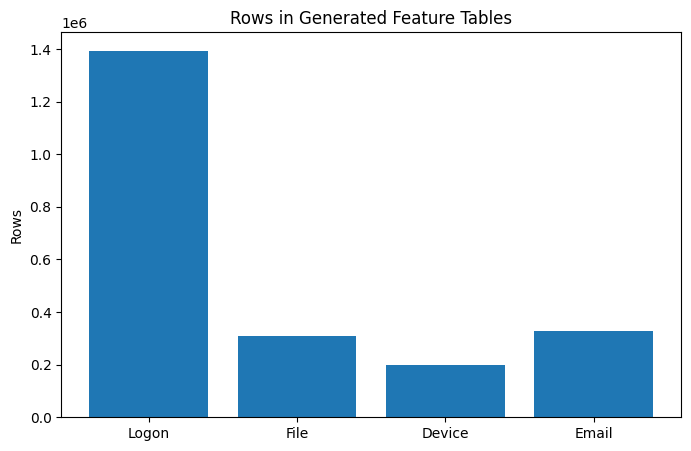

In [37]:
# ==========================================
# Visualization: Feature Table Sizes
# ==========================================

sizes = {
    "Logon": len(logon_features),
    "File": len(file_features),
    "Device": len(device_features),
    "Email": len(email_features)
}

plt.figure(figsize=(8,5))
plt.bar(sizes.keys(), sizes.values())
plt.title("Rows in Generated Feature Tables")
plt.ylabel("Rows")
plt.show()

In [38]:
# ==========================================
# Merge Final Feature Dataset
# ==========================================

features = logon_features.merge(
    file_features,
    on=["user", "day"],
    how="left"
).merge(
    device_features,
    on=["user", "day"],
    how="left"
).merge(
    email_features,
    on=["user", "day"],
    how="left"
)

features = features.fillna(0)

meta = features[["user", "day"]].copy()
X = features.drop(columns=["user", "day"])

print("Final dataset shape:", X.shape)
display(X.head())

Final dataset shape: (1394010, 14)


,logon_count,logoff_count,afterhours_logon,file_access_count,usb_write_count,usb_read_count,afterhours_file_access,usb_connect_count,usb_disconnect_count,afterhours_device,email_count,total_email_size,total_attachments,afterhours_email
0,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


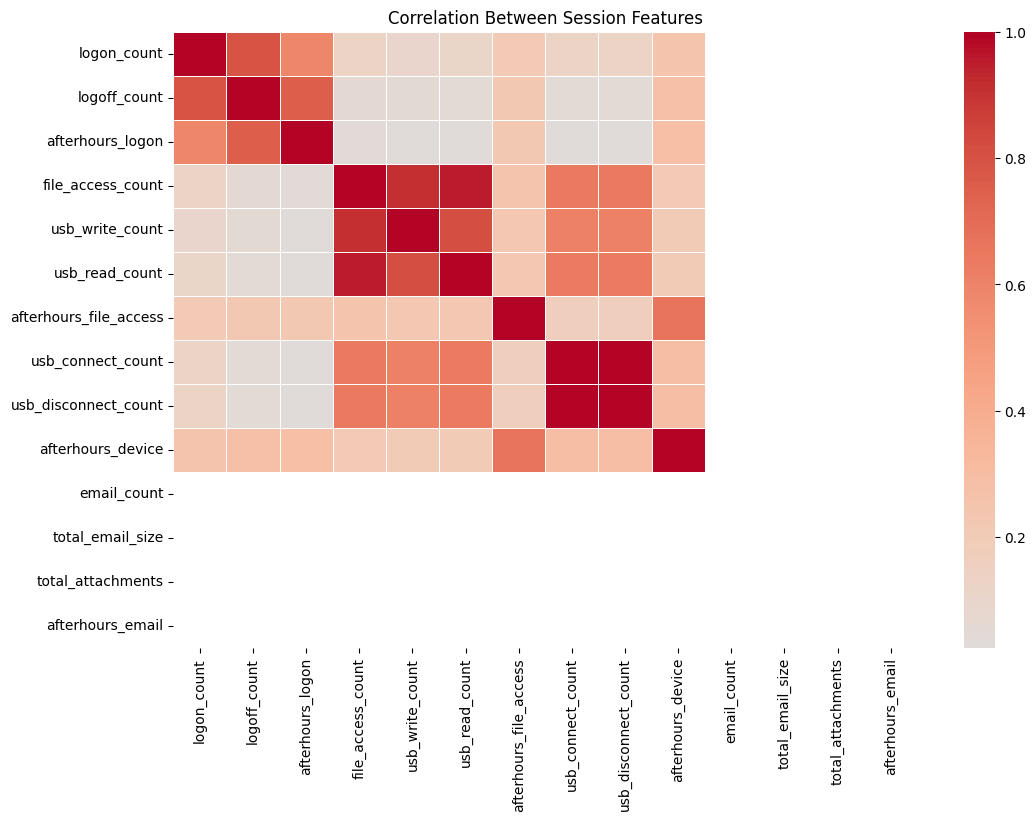

In [39]:
# ==========================================
# Visualization: Feature Correlation Heatmap
# ==========================================

plt.figure(figsize=(12,8))
sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Between Session Features")
plt.show()

In [40]:
# ==========================================
# Train-Test Split & Feature Scaling
# ==========================================

X_train, X_test, meta_train, meta_test = train_test_split(
    X,
    meta,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (1115208, 14)
Test shape : (278802, 14)


In [41]:
# ==========================================
# Train Isolation Forest Model
# ==========================================

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_scaled)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


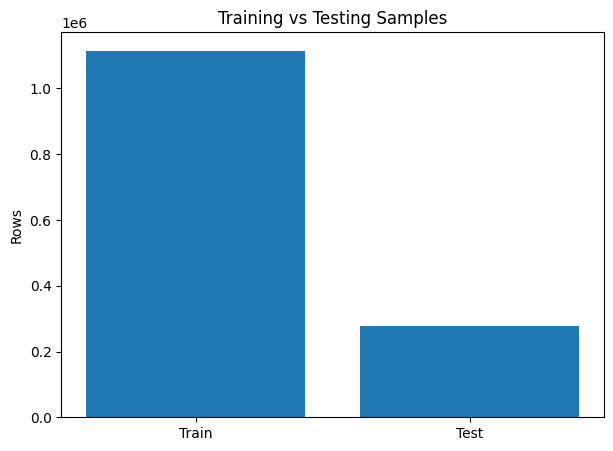

In [42]:
# ==========================================
# Visualization: Train vs Test Samples
# ==========================================

sizes = {
    "Train": len(X_train),
    "Test": len(X_test)
}

plt.figure(figsize=(7,5))
plt.bar(sizes.keys(), sizes.values())
plt.title("Training vs Testing Samples")
plt.ylabel("Rows")
plt.show()

In [43]:
# ==========================================
# Predict Session Anomalies
# ==========================================

pred = iso_model.predict(X_test_scaled)

# Convert: anomaly = 1, normal = 0
pred_label = (pred == -1).astype(int)

print("Total anomalies detected:", pred_label.sum())
print("Total normal sessions :", (pred_label == 0).sum())

Total anomalies detected: 5584
Total normal sessions : 273218


In [44]:
# ==========================================
# Create Results Table
# ==========================================

results = meta_test.reset_index(drop=True).copy()
results["is_anomaly"] = pred_label

display(results.head())

,user,day,is_anomaly
0,RRH3057,2011-01-31,0
1,AYS1628,2010-02-10,0
2,HVR0633,2010-10-29,0
3,AKL1305,2011-03-10,0
4,DHS2419,2011-04-07,0


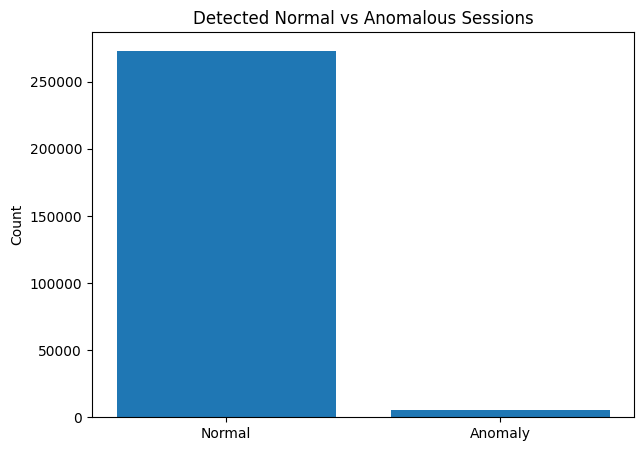

In [45]:
# ==========================================
# Visualization: Normal vs Anomaly Sessions
# ==========================================

counts = {
    "Normal": int((pred_label == 0).sum()),
    "Anomaly": int((pred_label == 1).sum())
}

plt.figure(figsize=(7,5))
plt.bar(counts.keys(), counts.values())
plt.title("Detected Normal vs Anomalous Sessions")
plt.ylabel("Count")
plt.show()

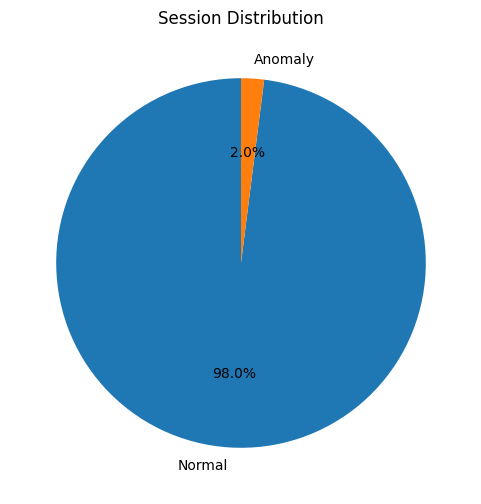

In [46]:
# ==========================================
# Visualization: Pie Distribution
# ==========================================

plt.figure(figsize=(6,6))
plt.pie(
    counts.values(),
    labels=counts.keys(),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Session Distribution")
plt.show()

In [47]:
# ==========================================
# Generate Anomaly Scores
# ==========================================

anomaly_scores = iso_model.decision_function(X_test_scaled)

In [48]:
# ==========================================
# Zero Trust Session Decisions
# ==========================================

def zero_trust_session_decision(score):
    if score > 0:
        return "NORMAL"
    elif score > -0.08:
        return "SUSPICIOUS"
    else:
        return "BLOCK"

decisions = [
    zero_trust_session_decision(score)
    for score in anomaly_scores
]

final_results = meta_test.reset_index(drop=True).copy()
final_results["anomaly_score"] = anomaly_scores
final_results["decision"] = decisions

display(final_results.head())

,user,day,anomaly_score,decision
0,RRH3057,2011-01-31,0.279331,NORMAL
1,AYS1628,2010-02-10,0.214804,NORMAL
2,HVR0633,2010-10-29,0.340976,NORMAL
3,AKL1305,2011-03-10,0.340976,NORMAL
4,DHS2419,2011-04-07,0.279795,NORMAL


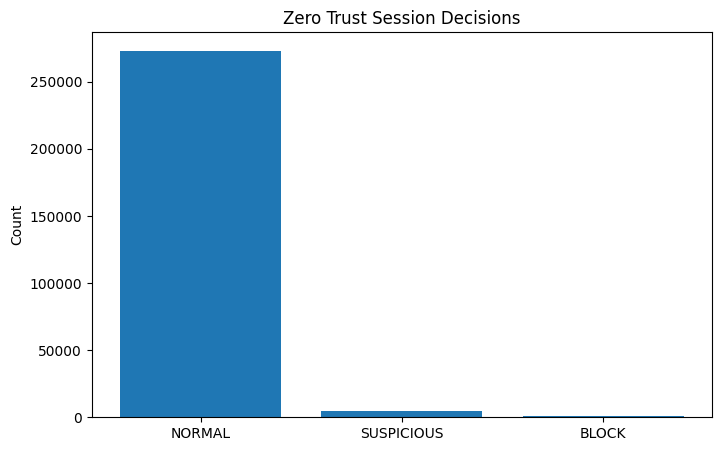

In [49]:
# ==========================================
# Visualization: Decision Distribution
# ==========================================

decision_counts = pd.Series(decisions).value_counts()

plt.figure(figsize=(8,5))
plt.bar(
    decision_counts.index,
    decision_counts.values
)
plt.title("Zero Trust Session Decisions")
plt.ylabel("Count")
plt.show()

In [51]:
# ==========================================
# Compute Dynamic Trust Score
# ==========================================

def compute_trust(norm_score, row):
    trust = norm_score

    if row["usb_write_count"] > 5:
        trust -= 0.2

    if row["file_access_count"] > 30:
        trust -= 0.2

    if row["afterhours_file_access"] > 3:
        trust -= 0.1

    if row["email_count"] > 20:
        trust -= 0.1

    return max(0, min(1, trust))

X_test_df = X_test.reset_index(drop=True).copy()
X_test_df["norm_score"] = norm_scores

X_test_df["trust_score"] = X_test_df.apply(
    lambda row: compute_trust(
        row["norm_score"],
        row
    ),
    axis=1
)

In [52]:
# ==========================================
# Final Trust Decisions
# ==========================================

def trust_decision(trust):
    if trust > 0.7:
        return "ALLOW"
    elif trust > 0.4:
        return "MFA"
    else:
        return "BLOCK"

X_test_df["trust_decision"] = X_test_df[
    "trust_score"
].apply(trust_decision)

display(
    X_test_df[
        ["trust_score", "trust_decision"]
    ].head()
)

,trust_score,trust_decision
0,0.834032,ALLOW
1,0.711181,ALLOW
2,0.951396,ALLOW
3,0.951396,ALLOW
4,0.834915,ALLOW


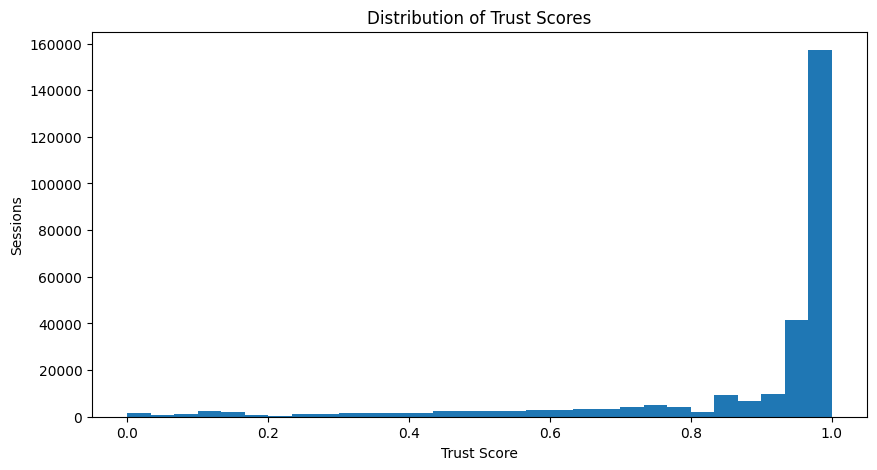

In [53]:
# ==========================================
# Visualization: Trust Score Distribution
# ==========================================

plt.figure(figsize=(10,5))
plt.hist(
    X_test_df["trust_score"],
    bins=30
)
plt.title("Distribution of Trust Scores")
plt.xlabel("Trust Score")
plt.ylabel("Sessions")
plt.show()

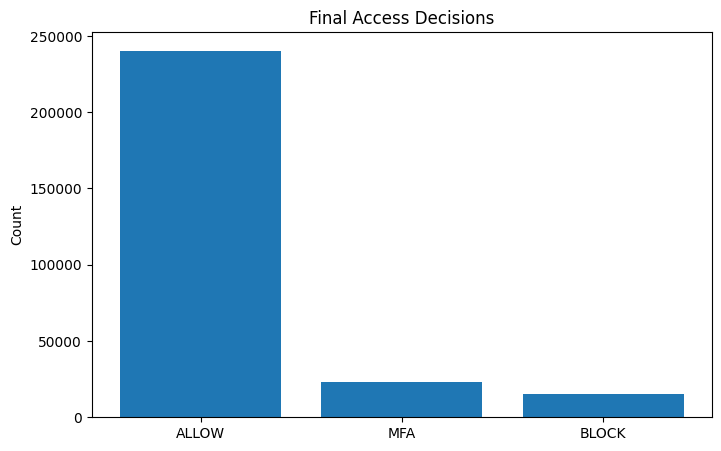

In [54]:
# ==========================================
# Visualization: Final Access Decisions
# ==========================================

final_counts = X_test_df["trust_decision"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(
    final_counts.index,
    final_counts.values
)
plt.title("Final Access Decisions")
plt.ylabel("Count")
plt.show()

In [55]:
# ==========================================
# Save Model Artifacts
# ==========================================

joblib.dump(iso_model, "session_model.pkl")
joblib.dump(scaler, "session_scaler.pkl")

feature_cols = X.columns.tolist()

with open("session_feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

print("Saved:")
print("- session_model.pkl")
print("- session_scaler.pkl")
print("- session_feature_cols.json")

Saved:
- session_model.pkl
- session_scaler.pkl
- session_feature_cols.json


In [57]:
# ==========================================
# Create Pseudo Ground Truth Labels
# ==========================================

# Lowest 2% scores treated as true anomalies
threshold = np.percentile(anomaly_scores, 2)

y_true = (anomaly_scores <= threshold).astype(int)
y_pred = pred_label

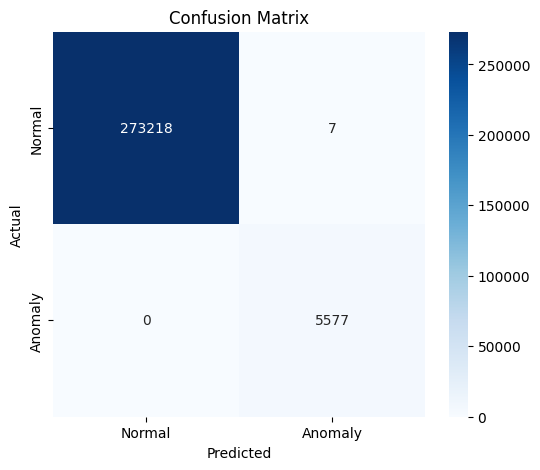

In [59]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Conclusion

The Session Monitoring Engine successfully detects abnormal user behavior using Isolation Forest and converts risk signals into trust-based access decisions.

This model powers real-time adaptive security in the ZeroTA system.